In [2]:
import pypsa
import fbmc  # noqa: F401  not unused; registers pypsa.Network.fbmc accessor
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx
import cartopy

In [34]:
nodal_net = pypsa.Network("base_s_25_elec_.nc")
nodal_net.buses.rename(columns={"country": "zone_name"}, inplace=True)
bus_zone_map = nodal_net.buses['zone_name']
zonal_net = nodal_net.fbmc.to_zonal(bus_zone_map)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units


Skipping missing attribute loss


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x14b4a8510>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x14b36d550>,
  'Line': <matplotlib.collections.LineCollection at 0x14b5946d0>},
 'flows': {}}

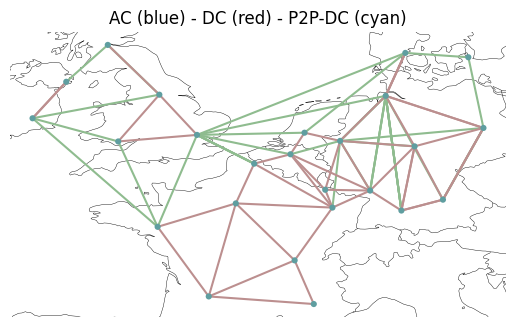

In [4]:
import cartopy
line_color = nodal_net.lines.bus0.map(nodal_net.buses.carrier).map(
    lambda ct: "r" if ct == "DC" else "b"
)

nodal_net.plot.map(
    title="AC (blue) - DC (red) - P2P-DC (cyan)",
    jitter=0.4,
)

In [31]:
nodal_net.statistics.energy_balance(aggregate_time=False, aggregate_across_components=True, groupby=["bus"]).sum()
nodal_net.statistics.energy_balance(aggregate_time=False, aggregate_across_components=False, groupby=["bus"])["2013-01-01 00:00:00"].groupby("component").sum()


component
Generator      156635.34330
Line            -3257.35041
Link               -0.00001
Load          -153000.77431
StorageUnit      -377.21822
Name: 2013-01-01 00:00:00, dtype: float64

In [19]:
nodal_net.buses_t.p.T.sum()

snapshot
2013-01-01 00:00:00    3257.350751
2013-01-01 01:00:00    3488.754268
2013-01-01 02:00:00    3535.996150
2013-01-01 03:00:00    3348.028681
2013-01-01 04:00:00    3407.271887
                          ...     
2013-12-30 19:00:00     991.151135
2013-12-30 20:00:00    1214.446103
2013-12-30 21:00:00    1276.374142
2013-12-30 22:00:00    1457.122286
2013-12-30 23:00:00    1194.102636
Length: 8736, dtype: float64

In [33]:
nodal_net.lines.columns

Index(['bus0', 'bus1', 'type', 'x', 'r', 'g', 'b', 's_nom', 's_nom_mod',
       's_nom_extendable', 's_nom_min', 's_nom_max', 's_max_pu',
       'capital_cost', 'active', 'build_year', 'lifetime', 'length', 'carrier',
       'terrain_factor', 'num_parallel', 'v_ang_min', 'v_ang_max',
       'sub_network', 'x_pu', 'r_pu', 'g_pu', 'b_pu', 'x_pu_eff', 'r_pu_eff',
       's_nom_opt', 'v_nom', 'i_nom', 'dc'],
      dtype='object')

In [39]:
import yaml

with open("config.base_s_25_elec_.yaml") as stream:
    try:
        config_original = (yaml.safe_load(stream))
    except yaml.YAMLError as exc:
        print(exc)

In [40]:
solver_options = config_original["solving"]["solver_options"]["gurobi-default"]
#solver_name = config_original["solving"][("solver")]
solver_name = {'solver_name': "gurobi"}
solver_options = solver_name | solver_options
solver_options

{'solver_name': 'gurobi',
 'threads': 32,
 'method': 2,
 'crossover': 0,
 'BarConvTol': 1e-05,
 'Seed': 123,
 'AggFill': 0,
 'PreDual': 0,
 'GURO_PAR_BARDENSETHRESH': 200}

In [43]:
solver_options = config_original["solving"]["solver_options"]["gurobi-default"]

In [46]:
snapshots = nodal_net.snapshots[:24]  # first 24 snapshots
nodal_net.optimize(snapshots=snapshots, solver_name='gurobi', solver_options=solver_options)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 32
 - method: 2
 - crossover: 0
 - BarConvTol: 1e-05
 - Seed: 123
 - AggFill: 0
 - PreDual: 0
 - GURO_PAR_BARDENSETHRESH: 200
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 681.54it/s]
INFO:linopy.io: Writing time: 0.07s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2838876


INFO:gurobipy:Set parameter LicenseID to value 2838876


...

INFO:gurobipy:Barrier solved model in 29 iterations and 0.28 seconds (0.26 work units)


Optimal objective 2.97971390e+07


INFO:gurobipy:Optimal objective 2.97971390e+07


INFO:gurobipy:
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 10192 primals, 22114 duals
Objective: 2.98e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [47]:
nodal_net.buses_t.p.T.sum()

snapshot
2013-01-01 00:00:00    2.576739e-07
2013-01-01 01:00:00    1.205678e-06
2013-01-01 02:00:00   -6.062919e-10
2013-01-01 03:00:00   -4.295850e-08
2013-01-01 04:00:00   -2.130548e-09
                           ...     
2013-12-30 19:00:00    9.911511e+02
2013-12-30 20:00:00    1.214446e+03
2013-12-30 21:00:00    1.276374e+03
2013-12-30 22:00:00    1.457122e+03
2013-12-30 23:00:00    1.194103e+03
Length: 8736, dtype: float64